Exp 7:
 Anomaly Detection: Implement an anomaly detection system
for detecting outliers in data (e.g., fraud detection) and perform
comparative analysis. (Isolation Forest, Local Outlier Factor,
One-Class SVM)

In [22]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.ensemble import IsolationForest
from sklearn.neighbors import LocalOutlierFactor
from sklearn.svm import OneClassSVM
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, precision_score, recall_score, f1_score

In [23]:
data=pd.read_csv('/content/drive/MyDrive/python-ml-lab/exp5_6_7_8/anomaly_detection_dataset_500_samples.csv')
data.head()

,Feature_1,Feature_2,Anomaly_Label
0,43.259073,53.716320,0
1,43.815246,43.397717,0
2,46.942411,42.966695,0
3,48.911594,55.493884,0
4,52.575238,69.263657,0


In [24]:
data.shape

(500, 3)

In [25]:
X = data[['Feature_1', 'Feature_2']]
y_true = data['Anomaly_Label']  # 0: Normal, 1: Anomaly

In [26]:
# Scaling is mandatory for LOF and One-Class SVM
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [27]:
# Set contamination based on expected outlier percentage (e.g., 5%)
contamination_rate = 0.05

# ---Create and Fit All Models ---

# Model 1: Isolation Forest
ISO = IsolationForest(contamination=contamination_rate, random_state=42)
y_pred_iso = ISO.fit_predict(X_scaled)
# Map: 1 (normal) -> 0, -1 (anomaly) -> 1
y_pred_iso = np.where(y_pred_iso == 1, 0, 1)

# Model 2: Local Outlier Factor
LOF = LocalOutlierFactor(contamination=contamination_rate)
y_pred_lof = LOF.fit_predict(X_scaled)
# Map: 1 (normal) -> 0, -1 (anomaly) -> 1
y_pred_lof = np.where(y_pred_lof == 1, 0, 1)

# Model 3: One-Class SVM
OCSVM = OneClassSVM(nu=contamination_rate, kernel='rbf', gamma=0.1)
y_pred_ocsvm = OCSVM.fit_predict(X_scaled)
# Map: 1 (normal) -> 0, -1 (anomaly) -> 1
y_pred_ocsvm = np.where(y_pred_ocsvm == 1, 0, 1)

In [28]:
# Accuracy Scores
iso_acc = accuracy_score(y_true, y_pred_iso)
lof_acc = accuracy_score(y_true, y_pred_lof)
oc_acc = accuracy_score(y_true, y_pred_ocsvm)

print(f"Isolation Forest Accuracy: {iso_acc:.4f}")
print(f"Local Outlier Factor Accuracy: {lof_acc:.4f}")
print(f"One-Class SVM Accuracy: {oc_acc:.4f}")

Isolation Forest Accuracy: 0.9660
Local Outlier Factor Accuracy: 0.8900
One-Class SVM Accuracy: 0.9320


In [29]:
# Precision
iso_prec = precision_score(y_true, y_pred_iso)
lof_prec = precision_score(y_true, y_pred_lof)
oc_prec = precision_score(y_true, y_pred_ocsvm)

print(f"Isolation Forest Precision: {iso_prec:.4f}")
print(f"Local Outlier Factor Precision: {lof_prec:.4f}")
print(f"One-Class SVM Precision: {oc_prec:.4f}")

Isolation Forest Precision: 0.7600
Local Outlier Factor Precision: 0.0000
One-Class SVM Precision: 0.4167


In [32]:
# Recall
iso_rec = recall_score(y_true, y_pred_iso)
lof_rec = recall_score(y_true, y_pred_lof)
oc_rec = recall_score(y_true, y_pred_ocsvm)

print(f"Isolation Forest Recall: {iso_rec:.4f}")
print(f"Local Outlier Factor Recall: {lof_rec:.4f}")
print(f"One-Class SVM Recall: {oc_rec:.4f}")

Isolation Forest Recall: 0.6333
Local Outlier Factor Recall: 0.0000
One-Class SVM Recall: 0.3333


In [33]:
# F1-Score
iso_f1 = f1_score(y_true, y_pred_iso)
lof_f1 = f1_score(y_true, y_pred_lof)
oc_f1 = f1_score(y_true, y_pred_ocsvm)

print(f"Isolation Forest F1-Score: {iso_f1:.4f}")
print(f"Local Outlier Factor F1-Score: {lof_f1:.4f}")
print(f"One-Class SVM F1-Score: {oc_f1:.4f}")


Isolation Forest F1-Score: 0.6909
Local Outlier Factor F1-Score: 0.0000
One-Class SVM F1-Score: 0.3704


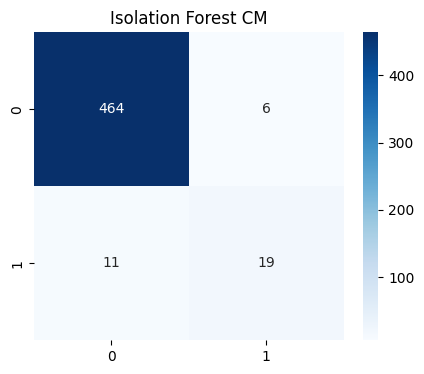

In [19]:
# --- Confusion Matrices ---

# Isolation Forest
plt.figure(figsize=(5,4))
sns.heatmap(confusion_matrix(y_true, y_pred_iso), annot=True, fmt='d', cmap='Blues')
plt.title("Isolation Forest CM")
plt.show()

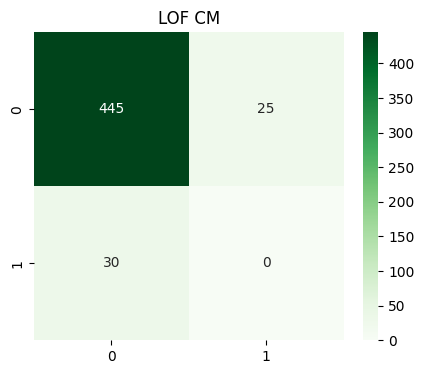

In [20]:
# LOF
plt.figure(figsize=(5,4))
sns.heatmap(confusion_matrix(y_true, y_pred_lof), annot=True, fmt='d', cmap='Greens')
plt.title("LOF CM")
plt.show()

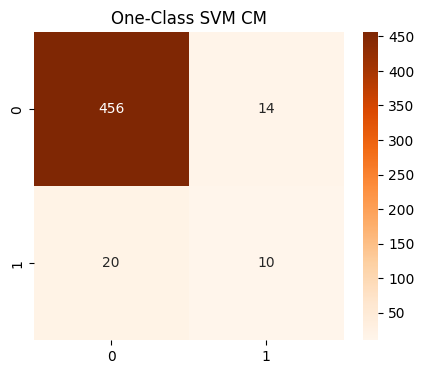

In [21]:
# One-Class SVM
plt.figure(figsize=(5,4))
sns.heatmap(confusion_matrix(y_true, y_pred_ocsvm), annot=True, fmt='d', cmap='Oranges')
plt.title("One-Class SVM CM")
plt.show()

In [38]:
# Saving the model
import pickle
import os

# Saving Isolation Forest model
with open('isolation_forest_model.pkl', 'wb') as f:
    pickle.dump(ISO, f)

# Saving Local Outlier Factor model
with open('lof_model.pkl', 'wb') as f:
    pickle.dump(LOF, f)

# Saving One-Class SVM model
with open('one_class_svm_model.pkl', 'wb') as f:
    pickle.dump(OCSVM, f)